# Forecasting A&E Four-Hour Performance Across English Hospitals

The goal of this project is to forecast how each major A&E department in England will perform against the four-hour standard, one month ahead, and wrap the result in an app where someone can pick a hospital and see its outlook.

This single notebook holds the whole project: building the dataset, exploring it, modelling, and preparing what the app needs. Each section starts by saying what we want to find out, then shows the result and what it tells us.

We work with **Type 1** departments only — the large, 24/7, consultant-led A&Es. The smaller walk-in and minor-injury units (Type 3) see almost everyone within four hours and would hide the pressure we are trying to measure.

## 1. Building the dataset

We want one tidy table: for every major A&E, in every month, the share of patients seen within four hours. NHS England publishes this as one file per month, so the job here is to gather those files and combine them into a single table covering 2018 onward.

**First, where do the monthly files live?**

NHS England lists them on a separate web page for each financial year. The file links are not predictable — the names have random endings. So rather than guess them, we read each year's page and pick out the links that point to a monthly CSV.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import re

BASE = "https://www.england.nhs.uk"

YEAR_PAGES = {
    "2026-27": BASE + "/statistics/statistical-work-areas/ae-waiting-times-and-activity/ae-attendances-and-emergency-admissions-2026-27/",
    "2025-26": BASE + "/statistics/statistical-work-areas/ae-waiting-times-and-activity/ae-attendances-and-emergency-admissions-2025-26/",
    "2024-25": BASE + "/statistics/statistical-work-areas/ae-waiting-times-and-activity/ae-attendances-and-emergency-admissions-2024-25/",
    "2023-24": BASE + "/statistics/statistical-work-areas/ae-waiting-times-and-activity/ae-attendances-and-emergency-admissions-2023-24/",
    "2022-23": BASE + "/statistics/statistical-work-areas/ae-waiting-times-and-activity/ae-attendances-and-emergency-admissions-2022-23/",
    "2021-22": BASE + "/statistics/statistical-work-areas/ae-waiting-times-and-activity/ae-attendances-and-emergency-admissions-2021-22/",
    "2020-21": BASE + "/statistics/statistical-work-areas/ae-waiting-times-and-activity/ae-attendances-and-emergency-admissions-2020-21/",
    "2019-20": BASE + "/statistics/statistical-work-areas/ae-waiting-times-and-activity/ae-attendances-and-emergency-admissions-2019-20/",
    "2018-19": BASE + "/statistics/statistical-work-areas/ae-waiting-times-and-activity/ae-attendances-and-emergency-admissions-2018-19/",
}


def find_csv_links(page_html):
    links = re.findall(r'href="([^"]+\.csv)"', page_html, flags=re.IGNORECASE)
    # Skip the quarterly files; we only want the monthly ones.
    monthly = [l for l in links if "quarter" not in l.lower()]
    full = [l if l.startswith("http") else BASE + l for l in monthly]
    return list(dict.fromkeys(full))   # drop duplicates, keep order

That gives us the download links for any year. Next we need a way to turn one raw monthly file into just the columns we care about.

**Turning one raw file into the rows we want.**

Each file gives raw counts, not a performance figure, so we work it out ourselves: the share seen within four hours is one minus (attendances over four hours / total attendances). The column names also changed slightly over the years — older files write "Number of ..." and use different capitalisation — so we tidy the names first so every year lines up. Let's write the function, run it on one recent month, and look at what comes out.

In [4]:
import pandas as pd
import requests

HEADERS = {"User-Agent": "ae-panel-research/1.0"}
MONTHS = {"JANUARY": 1, "FEBRUARY": 2, "MARCH": 3, "APRIL": 4, "MAY": 5, "JUNE": 6,
          "JULY": 7, "AUGUST": 8, "SEPTEMBER": 9, "OCTOBER": 10, "NOVEMBER": 11, "DECEMBER": 12}


def load_month(path):
    df = pd.read_csv(path)
    df.columns = [c.lower().replace("number of ", "").strip() for c in df.columns]

    # "Period" reads like MSitAE-MARCH-2026: month name then year at the end.
    period = str(df["period"].iloc[0]).upper().split("-")
    month = pd.Timestamp(int(period[-1]), MONTHS[period[-2]], 1)

    out = pd.DataFrame({
        "month": month,
        "org_code": df["org code"].str.strip(),
        "region": df["parent org"].str.strip(),
        "org_name": df["org name"].str.strip(),
        "attendances": df["a&e attendances type 1"],
        "over_4hrs": df["attendances over 4hrs type 1"],
        "admissions": df["emergency admissions via a&e - type 1"],
    })
    # Keep only hospitals that actually ran a major A&E that month.
    out = out[out["attendances"] > 0].copy()
    out["within_4hrs"] = 1 - out["over_4hrs"] / out["attendances"]
    return out.reset_index(drop=True)


# Test on the most recent month: read the latest year page, take its first CSV.
latest_page = requests.get(YEAR_PAGES["2025-26"], headers=HEADERS, timeout=60).text
sample_url = find_csv_links(latest_page)[0]
sample_file = "sample_month.csv"
open(sample_file, "wb").write(requests.get(sample_url, headers=HEADERS, timeout=60).content)

sample = load_month(sample_file)
print(sample.shape)
sample.head()

(122, 8)


,month,org_code,region,org_name,attendances,over_4hrs,admissions,within_4hrs
0,2026-03-01,RWF,NHS ENGLAND SOUTH EAST,MAIDSTONE AND TUNBRIDGE WELLS NHS TRUST,19931,4411,2314,0.778686
1,2026-03-01,RWY,NHS ENGLAND NORTH EAST AND YORKSHIRE,CALDERDALE AND HUDDERSFIELD NHS FOUNDATION TRUST,16023,1957,3004,0.877863
2,2026-03-01,RFF,NHS ENGLAND NORTH EAST AND YORKSHIRE,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,9452,1843,3372,0.805015
3,2026-03-01,RGP,NHS ENGLAND EAST OF ENGLAND,JAMES PAGET UNIVERSITY HOSPITALS NHS FOUNDATIO...,7717,2678,1586,0.652974
4,2026-03-01,RQX,NHS ENGLAND LONDON,HOMERTON HEALTHCARE NHS FOUNDATION TRUST,11459,1708,1966,0.850947


**Now do it for every month, 2018 onward.**

We go through each year's page, download every monthly file, and run the same function on it. Some months will be missing or will not load — a handful of trusts stopped reporting four-hour data during a national pilot between 2019 and 2023 — so instead of letting one bad file stop everything, we keep a small log of what loaded and what was skipped.

In [5]:
import time

all_months = []
log = []

for year, page_url in YEAR_PAGES.items():
    try:
        page_html = requests.get(page_url, headers=HEADERS, timeout=60).text
    except Exception as exc:
        log.append({"file": page_url, "status": "page failed", "detail": str(exc)})
        continue

    for url in find_csv_links(page_html):
        name = url.split("/")[-1]
        try:
            content = requests.get(url, headers=HEADERS, timeout=60).content
            open(name, "wb").write(content)
            time.sleep(1)   # small pause so we are not hammering the server
            all_months.append(load_month(name))
            log.append({"file": name, "status": "loaded", "detail": ""})
        except Exception as exc:
            log.append({"file": name, "status": "skipped", "detail": str(exc)})

panel = (pd.concat(all_months, ignore_index=True)
           .drop_duplicates(["org_code", "month"])
           .sort_values(["org_code", "month"])
           .reset_index(drop=True))
log = pd.DataFrame(log)

The panel is now built. Before we analyse anything, we check it is trustworthy — its size, whether any months were skipped, and whether the numbers match what we already know about A&E.

In [6]:
print("Panel:", panel.shape[0], "rows |",
      panel["org_code"].nunique(), "hospitals |",
      panel["month"].nunique(), "months |",
      panel["month"].min().date(), "to", panel["month"].max().date())

print("\nLoad results:")
print(log["status"].value_counts().to_string())

skipped = log[log["status"] == "skipped"]
if len(skipped):
    print("\nSkipped files:")
    print(skipped[["file", "detail"]].to_string(index=False))

# Reality check: average performance each March, year by year.
march = panel[panel["month"].dt.month == 3]
print("\nAverage % seen within 4 hours, each March:")
print(march.groupby(march["month"].dt.year)["within_4hrs"].mean().round(3).to_string())

Panel: 12451 rows | 144 hospitals | 98 months | 2018-04-01 to 2026-05-01

Load results:
status
loaded    98

Average % seen within 4 hours, each March:
month
2019    0.800
2020    0.799
2021    0.826
2022    0.635
2023    0.619
2024    0.605
2025    0.604
2026    0.636


In [7]:
panel.to_csv("/content/drive/MyDrive/ae_panel.csv", index=False)
log.to_csv("/content/drive/MyDrive/ingestion_log.csv", index=False)
print("Saved to Drive")

Saved ae_panel.csv and ingestion_log.csv


## 2. Exploring the data

With a panel we trust, the next questions decide how we model it. We will work through these one at a time in the cells below:

- How performance has moved over the whole period, and how sharply COVID (early 2020 onward) breaks the pattern.
- Which hospitals are missing months, and when, so those gaps are handled honestly rather than treated as real values.
- Whether specialist hospitals such as children's trusts behave so differently that they do not belong with the general acute hospitals.
- How many hospitals are present in every single month, since the set changes over time through mergers and closures — this is the group we can model cleanly.

### 2.1 When does performance break?

The yearly March snapshots showed performance holding near 80% through 2021, then sitting in the low 60s from 2022 on. But one month a year can't tell us when the drop happened or whether it was gradual or sudden. So we plot the average performance across all hospitals for every month, and look at the full path.

### 2.1a Data integrity check

Before any analysis, confirm the panel is sound: correct data types, no impossible values, no missing or empty months hiding inside files that loaded cleanly, and no leftover duplicates.

In [8]:
print("Data types:")
print(panel.dtypes.to_string())

print("\nMissing values per column:")
print(panel.isna().sum().to_string())

print("\nImpossible values:")
print("  negative attendances:", (panel["attendances"] < 0).sum())
print("  over_4hrs exceeds attendances:", (panel["over_4hrs"] > panel["attendances"]).sum())
print("  within_4hrs outside 0-1:", ((panel["within_4hrs"] < 0) | (panel["within_4hrs"] > 1)).sum())
print("  zero-attendance months:", (panel["attendances"] == 0).sum())

print("\nDuplicate (hospital, month) rows:", panel.duplicated(["org_code", "month"]).sum())

# How complete is each hospital's history? Count present months vs the 98 possible.
present = panel.groupby("org_code")["month"].nunique()
total_months = panel["month"].nunique()
print(f"\nHospitals with gaps (fewer than {total_months} months):", (present < total_months).sum())
print("Distribution of months-present:")
print(present.value_counts().sort_index().tail(10).to_string())

Data types:
month          datetime64[us]
org_code               object
region                 object
org_name               object
attendances             int64
over_4hrs               int64
admissions              int64
within_4hrs           float64

Missing values per column:
month           0
org_code       12
region         12
org_name        0
attendances     0
over_4hrs       0
admissions      0
within_4hrs     0

Impossible values:
  negative attendances: 0
  over_4hrs exceeds attendances: 0
  within_4hrs outside 0-1: 0
  zero-attendance months: 0

Duplicate (hospital, month) rows: 0

Hospitals with gaps (fewer than 98 months): 27
Distribution of months-present:
month
48      1
60      1
63      1
68      1
70      1
74      1
80      1
81      1
86      1
98    117


### 2.1b Remove non-hospital rows

Twelve rows have a name but no organisation code. These are summary or totals lines from the source files, not hospitals. We confirm what they are, then drop them.

In [13]:
# Look at the rows with no org_code.
no_code = panel[panel["org_code"].isna()]
print("Rows with no org_code:", len(no_code))
print(no_code["org_name"].value_counts().to_string())

# Drop them: a real hospital always has a code.
panel = panel.dropna(subset=["org_code"]).copy()
print("\nPanel after removing them:", panel.shape)

Rows with no org_code: 12
org_name
TOTAL    6
Total    6

Panel after removing them: (12353, 8)


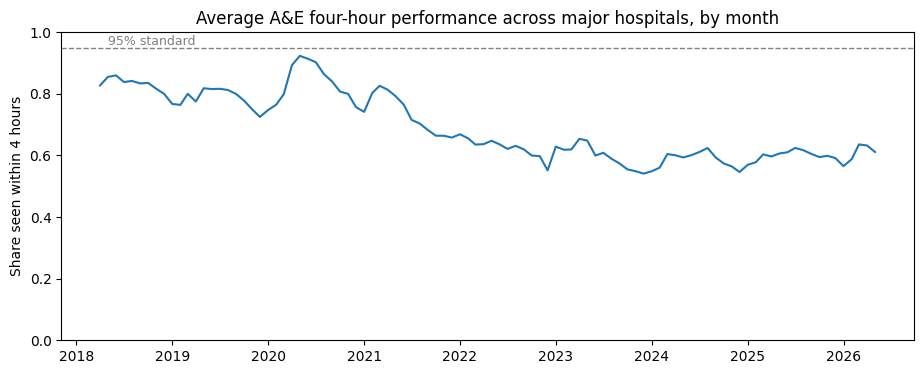

In [14]:
import matplotlib.pyplot as plt

monthly = panel.groupby("month")["within_4hrs"].mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly.values)
ax.axhline(0.95, linestyle="--", linewidth=1, color="grey")
ax.text(monthly.index[1], 0.96, "95% standard", color="grey", fontsize=9)
ax.set_title("Average A&E four-hour performance across major hospitals, by month")
ax.set_ylabel("Share seen within 4 hours")
ax.set_ylim(0, 1)
plt.show()

### 2.2 Do all hospitals move together?

The average hides the spread. We plot every hospital's monthly performance as a faint line behind the average, then pull out the few that sit furthest from the pack.

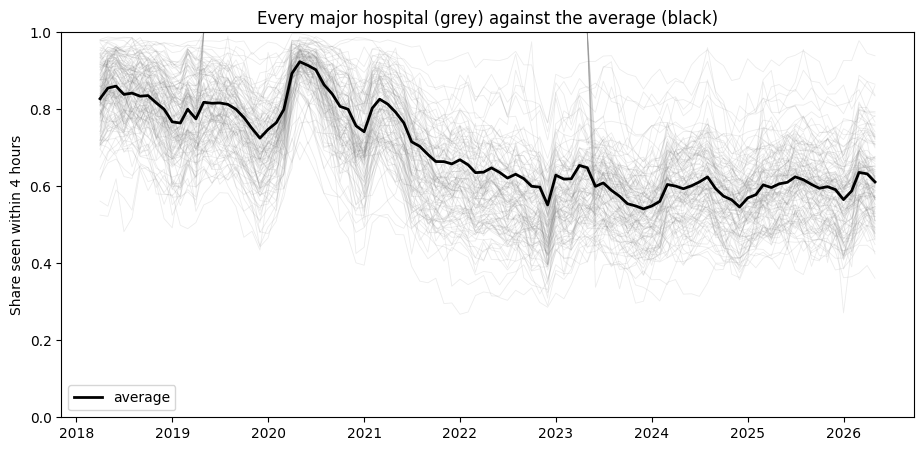

Highest average performers:
org_code  org_name                                                    
RC9       LUTON AND DUNSTABLE UNIVERSITY HOSPITAL NHS FOUNDATION TRUST    0.985
RXF       MID YORKSHIRE HOSPITALS NHS TRUST                               0.964
RDE       COLCHESTER HOSPITAL UNIVERSITY NHS FOUNDATION TRUST             0.950
RE9       SOUTH TYNESIDE NHS FOUNDATION TRUST                             0.940
RCU       SHEFFIELD CHILDREN'S NHS FOUNDATION TRUST                       0.937

Lowest average performers:
org_code  org_name                                                             
RCB       YORK AND SCARBOROUGH TEACHING HOSPITALS NHS FOUNDATION TRUST             0.471
RXW       THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST                            0.478
RAX       KINGSTON AND RICHMOND NHS FOUNDATION TRUST                               0.488
RWH       EAST AND NORTH HERTFORDSHIRE TEACHING NHS TRUST                          0.492
RRF       WRIGHTINGTON, WIGAN AND LEI

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))

for code, g in panel.groupby("org_code"):
    ax.plot(g["month"], g["within_4hrs"], color="grey", alpha=0.15, linewidth=0.6)

monthly = panel.groupby("month")["within_4hrs"].mean()
ax.plot(monthly.index, monthly.values, color="black", linewidth=2, label="average")

ax.set_title("Every major hospital (grey) against the average (black)")
ax.set_ylabel("Share seen within 4 hours")
ax.set_ylim(0, 1)
ax.legend()
plt.show()

# Which hospitals sit furthest from everyone else, on average?
avg_by_trust = panel.groupby(["org_code", "org_name"])["within_4hrs"].mean()
print("Highest average performers:")
print(avg_by_trust.sort_values(ascending=False).head(5).round(3).to_string())
print("\nLowest average performers:")
print(avg_by_trust.sort_values().head(5).round(3).to_string())

### 2.3 Who is actually present, and for how long?

A high average means little if a hospital only reported in its better years. Before comparing hospitals or choosing a training window, we check how many months each one actually has, and whether the top performers are simply missing the bad ones.

In [11]:
months_present = panel.groupby(["org_code", "org_name"])["month"].count().sort_values()

print("Total months in the panel:", panel["month"].nunique())
print("\nFewest months reported:")
print(months_present.head(8).to_string())

print("\nMonths reported by the five 'highest performers':")
for code in ["RC9", "RXF", "RDE", "RE9", "RCU"]:
    sub = panel[panel["org_code"] == code]
    print(f"  {code}: {len(sub)} months, {sub['month'].min().date()} to {sub['month'].max().date()}")

Total months in the panel: 98

Fewest months reported:
org_code  org_name                                                             
TOTAl     TOTAl                                                                    1
RWW       NORTH CHESHIRE AND MERSEY NHS FOUNDATION TRUST                           2
RGQ       IPSWICH HOSPITAL NHS TRUST                                               3
RDE       COLCHESTER HOSPITAL UNIVERSITY NHS FOUNDATION TRUST                      3
RR1       HEART OF ENGLAND NHS FOUNDATION TRUST                                    3
RJF       BURTON HOSPITALS NHS FOUNDATION TRUST                                    3
RTG       DERBY TEACHING HOSPITALS NHS FOUNDATION TRUST                            3
RRF       WRIGHTINGTON, WIGAN AND LEIGH TEACHING HOSPITALS NHS FOUNDATION TRUST    5

Months reported by the five 'highest performers':
  RC9: 98 months, 2018-04-01 to 2026-05-01
  RXF: 98 months, 2018-04-01 to 2026-05-01
  RDE: 98 months, 2018-04-01 to 2026-05-01
  RE9

### 2.4 A clean, consistent set of hospitals

The panel mixes hospitals with full histories against others that appear only briefly, usually because they merged into larger trusts, plus a stray totals row. A model needs a consistent set, so we drop the totals row and keep only hospitals that report in every month of the period we model.

In [12]:
# Drop the stray totals row that slipped past the filter.
panel = panel[panel["org_code"].str.upper() != "TOTAL"].copy()

# Count how many hospitals survive if we require a full history from a given start.
for start in ["2018-04-01", "2021-04-01", "2022-04-01"]:
    window = panel[panel["month"] >= start]
    n_months = window["month"].nunique()
    counts = window.groupby("org_code")["month"].count()
    full = (counts == n_months).sum()
    print(f"from {start}: {n_months} months, {full} hospitals with the full history")

from 2018-04-01: 98 months, 117 hospitals with the full history
from 2021-04-01: 62 months, 121 hospitals with the full history
from 2022-04-01: 50 months, 121 hospitals with the full history


### 2.5 How strong is the winter pattern?

Performance dipped each winter in the monthly plot. That seasonal pattern is the strongest signal a forecast can lean on, so we measure it: average performance by calendar month across the 2022-onward modelling period.

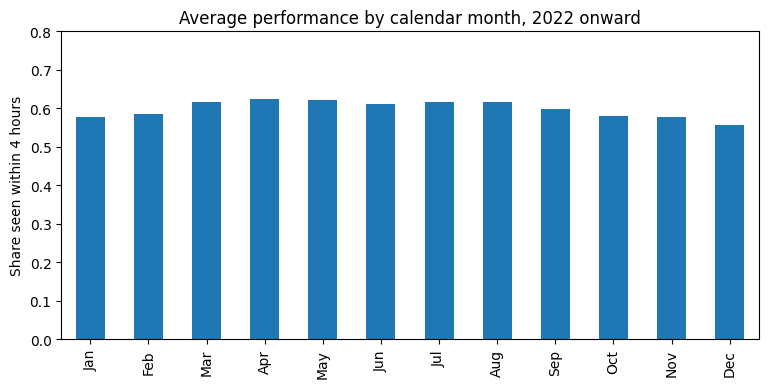

Jan    0.578
Feb    0.586
Mar    0.616
Apr    0.624
May    0.622
Jun    0.612
Jul    0.616
Aug    0.616
Sep    0.598
Oct    0.581
Nov    0.578
Dec    0.558


In [16]:
model_panel = panel[panel["month"] >= "2022-04-01"].copy()

by_calendar_month = (model_panel.groupby(model_panel["month"].dt.month)["within_4hrs"]
                     .mean().round(3))
by_calendar_month.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                           "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(9, 4))
by_calendar_month.plot(kind="bar", ax=ax)
ax.set_title("Average performance by calendar month, 2022 onward")
ax.set_ylabel("Share seen within 4 hours")
ax.set_ylim(0, 0.8)
plt.show()

print(by_calendar_month.to_string())

### 3. Feature engineering

We turn each hospital's history into inputs a model can predict from. Every feature for a given month uses only earlier months, so the model never sees the future it is meant to predict. Features are built per hospital, then we drop the early rows that have no history to draw on.

In [17]:
model_panel = panel[panel["month"] >= "2022-04-01"].sort_values(["org_code", "month"]).copy()

g = model_panel.groupby("org_code")["within_4hrs"]

# Last month, and two and three months back: recent performance is the strongest signal.
model_panel["lag_1"] = g.shift(1)
model_panel["lag_2"] = g.shift(2)
model_panel["lag_3"] = g.shift(3)

# Rolling average of the last 3 months: the recent level, smoothed.
# shift(1) first so the current month is never included in its own average.
model_panel["roll_3"] = g.shift(1).rolling(3).mean()

# Change since last month: is the hospital improving or sliding?
model_panel["trend_1"] = model_panel["lag_1"] - model_panel["lag_2"]

# The same month last year: captures the winter dip directly.
model_panel["lag_12"] = g.shift(12)

# Calendar month, so the model can learn the seasonal pattern.
model_panel["calendar_month"] = model_panel["month"].dt.month

# Drop rows where the longest lookback (12 months) isn't available yet.
features = ["lag_1", "lag_2", "lag_3", "roll_3", "trend_1", "lag_12", "calendar_month"]
model_panel = model_panel.dropna(subset=features).copy()

print("Rows ready for modelling:", len(model_panel))
print("Hospitals:", model_panel["org_code"].nunique())
print("Months:", model_panel["month"].min().date(), "to", model_panel["month"].max().date())
model_panel[["org_name", "month", "within_4hrs"] + features].head()

Rows ready for modelling: 4622
Hospitals: 123
Months: 2023-04-01 to 2026-05-01


,org_name,month,within_4hrs,lag_1,lag_2,lag_3,roll_3,trend_1,lag_12,calendar_month
60,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,2023-04-01,0.577248,0.450656,0.378015,0.396439,0.408370,0.072640,0.512606,4
61,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,2023-05-01,0.597521,0.577248,0.450656,0.378015,0.468640,0.126592,0.529339,5
62,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,2023-06-01,0.636507,0.597521,0.577248,0.450656,0.541808,0.020273,0.501102,6
63,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,2023-07-01,0.583322,0.636507,0.597521,0.577248,0.603759,0.038986,0.480960,7
64,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,2023-08-01,0.590701,0.583322,0.636507,0.597521,0.605783,-0.053185,0.494263,8


### 4. The baseline to beat

Before any model, we set the bar: predicting that next month equals this month (persistence). A&E performance moves slowly, so this is a strong, honest baseline. Any model we build has to beat it to be worth anything.

In [18]:
from sklearn.metrics import mean_absolute_error

# Time-based split: last 6 months are the test set, everything earlier trains.
cutoff = model_panel["month"].max() - pd.DateOffset(months=6)
train = model_panel[model_panel["month"] <= cutoff]
test = model_panel[model_panel["month"] > cutoff]

print("Train rows:", len(train), "| Test rows:", len(test))
print("Test window:", test["month"].min().date(), "to", test["month"].max().date())

# Persistence: next month = last month. That is exactly our lag_1 feature.
baseline_pred = test["lag_1"]
baseline_mae = mean_absolute_error(test["within_4hrs"], baseline_pred)

print(f"\nPersistence baseline MAE: {baseline_mae:.4f}")
print(f"  (on average {baseline_mae*100:.1f} percentage points off per hospital-month)")

Train rows: 3896 | Test rows: 726
Test window: 2025-12-01 to 2026-05-01

Persistence baseline MAE: 0.0327
  (on average 3.3 percentage points off per hospital-month)


### 5. XGBoost with time-series cross-validation

The baseline to beat is 0.0327. We tune XGBoost using TimeSeriesSplit: five expanding folds that always train on earlier months and validate on later ones, so the tuning respects time and never leaks the future. The best settings are then judged once on the sealed test months.

In [19]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor

features = ["lag_1", "lag_2", "lag_3", "roll_3", "trend_1", "lag_12", "calendar_month"]

# Sort training rows by month so each CV fold trains on earlier months and
# validates on later ones.
train_sorted = train.sort_values("month").reset_index(drop=True)
X_train, y_train = train_sorted[features], train_sorted["within_4hrs"]
X_test, y_test = test[features], test["within_4hrs"]

cv = TimeSeriesSplit(n_splits=5)

grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
}

search = GridSearchCV(XGBRegressor(random_state=0),
                      grid, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
search.fit(X_train, y_train)

print("Best settings:", search.best_params_)
print(f"Best cross-validated MAE: {-search.best_score_:.4f}")

best = search.best_estimator_
xgb_mae = mean_absolute_error(y_test, best.predict(X_test))
print(f"\nXGBoost test MAE:     {xgb_mae:.4f}")
print(f"Persistence baseline: {baseline_mae:.4f}")
gain = baseline_mae - xgb_mae
print(f"Improvement: {gain:.4f} ({gain / baseline_mae * 100:.1f}%)")

# Which features the model leans on.
importance = pd.Series(best.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importance:")
print(importance.round(3).to_string())

Best settings: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best cross-validated MAE: 0.0276

XGBoost test MAE:     0.0293
Persistence baseline: 0.0327
Improvement: 0.0034 (10.4%)

Feature importance:
lag_1             0.757
roll_3            0.105
calendar_month    0.040
lag_2             0.039
lag_3             0.027
lag_12            0.023
trend_1           0.009


### 6. Where does the model fail?

A single error number can hide trouble. We look at the test errors by month, by hospital, and against how predictable each hospital is, to see whether the model is reliable everywhere or only on average.

In [20]:
test_eval = test.copy()
test_eval["predicted"] = best.predict(X_test)
test_eval["error"] = test_eval["predicted"] - test_eval["within_4hrs"]
test_eval["abs_error"] = test_eval["error"].abs()

# Error by test month: is any month much worse (e.g. the winter dip)?
print("MAE by test month:")
print(test_eval.groupby(test_eval["month"].dt.to_period("M"))["abs_error"].mean().round(4).to_string())

# Bias check: does the model systematically over- or under-predict?
print(f"\nMean error (bias): {test_eval['error'].mean():+.4f}  (near zero = no systematic lean)")

# The worst single misses.
print("\nLargest misses:")
worst = test_eval.nlargest(5, "abs_error")[["org_name", "month", "within_4hrs", "predicted", "abs_error"]]
print(worst.to_string(index=False))

# Are unstable hospitals the hard ones? Compare each hospital's error to how much
# it bounces around month to month (its volatility in the training period).
vol = train.groupby("org_code")["within_4hrs"].std().rename("volatility")
per_hosp = test_eval.groupby("org_code")["abs_error"].mean().rename("test_mae")
check = pd.concat([vol, per_hosp], axis=1).dropna()
print(f"\nCorrelation between a hospital's volatility and its error: {check['volatility'].corr(check['test_mae']):+.2f}")
print("(positive = the model struggles most with the jumpiest hospitals, which is expected and honest)")

MAE by test month:
month
2025-12    0.0217
2026-01    0.0403
2026-02    0.0247
2026-03    0.0350
2026-04    0.0244
2026-05    0.0300
Freq: M

Mean error (bias): +0.0037  (near zero = no systematic lean)

Largest misses:
                                          org_name      month  within_4hrs  predicted  abs_error
  CHESTERFIELD ROYAL HOSPITAL NHS FOUNDATION TRUST 2026-01-01     0.271239   0.498574   0.227335
                   GEORGE ELIOT HOSPITAL NHS TRUST 2026-03-01     0.888473   0.725590   0.162883
 LONDON NORTH WEST UNIVERSITY HEALTHCARE NHS TRUST 2026-03-01     0.667414   0.515490   0.151925
                      WALSALL HEALTHCARE NHS TRUST 2026-03-01     0.813488   0.668698   0.144790
SOUTH TYNESIDE AND SUNDERLAND NHS FOUNDATION TRUST 2026-03-01     0.648267   0.509162   0.139105

Correlation between a hospital's volatility and its error: +0.06
(positive = the model struggles most with the jumpiest hospitals, which is expected and honest)


### 7. Keras LSTM: does the sequence help?

XGBoost got hand-built features. The LSTM instead reads each hospital's last 12 months as a sequence and learns the pattern itself. Same test months, same metric. The network is kept small with dropout and early stopping, since the data is short and a large model would overfit. Train, validation, and test are split by time.

In [21]:
import numpy as np

LOOKBACK = 12

# Hospitals with the full post-2022 history, so every sequence is the same length.
post = panel[panel["month"] >= "2022-04-01"].copy()
counts = post.groupby("org_code")["month"].nunique()
keep = counts[counts == counts.max()].index
seq_panel = post[post["org_code"].isin(keep)].sort_values(["org_code", "month"])

def build_sequences(df, lookback):
    X, y, dates = [], [], []
    for _, g in df.groupby("org_code"):
        g = g.sort_values("month")
        vals = g["within_4hrs"].to_numpy()
        month_frac = g["month"].dt.month.to_numpy() / 12.0   # season as a 0-1 channel
        d = g["month"].to_numpy()
        for i in range(lookback, len(g)):
            X.append(np.column_stack([vals[i-lookback:i], month_frac[i-lookback:i]]))
            y.append(vals[i])
            dates.append(d[i])
    return np.array(X), np.array(y), np.array(dates)

X, y, dates = build_sequences(seq_panel, LOOKBACK)

# Time-ordered split: test = last 6 months (sealed), validation = 6 before that, train = earlier.
test_mask = dates >= np.datetime64("2025-12-01")
val_mask = (dates >= np.datetime64("2025-06-01")) & (dates < np.datetime64("2025-12-01"))
train_mask = dates < np.datetime64("2025-06-01")

X_tr, y_tr = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_te, y_te = X[test_mask], y[test_mask]
print("train/val/test sequences:", len(X_tr), len(X_val), len(X_te))

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(0)
np.random.seed(0)

model = Sequential([
    LSTM(32, input_shape=(LOOKBACK, 2)),
    Dropout(0.2),
    Dense(1),
])
model.compile(optimizer="adam", loss="mae")

stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                    epochs=100, batch_size=64, callbacks=[stop], verbose=0)

lstm_pred = model.predict(X_te, verbose=0).ravel()
lstm_mae = mean_absolute_error(y_te, lstm_pred)

print(f"\nStopped after {len(history.history['loss'])} epochs")
print(f"\n{'Persistence baseline':22}{baseline_mae:.4f}")
print(f"{'XGBoost':22}{xgb_mae:.4f}")
print(f"{'LSTM':22}{lstm_mae:.4f}")

train/val/test sequences: 3146 726 726


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Stopped after 22 epochs

Persistence baseline  0.0327
XGBoost               0.0293
LSTM                  0.0320


In [22]:
import joblib

final_features = ["lag_1", "lag_2", "lag_3", "roll_3", "trend_1", "lag_12", "calendar_month"]

# Retrain on every available month for production.
full = model_panel.sort_values(["org_code", "month"])
production_model = XGBRegressor(**search.best_params_, random_state=0)
production_model.fit(full[final_features], full["within_4hrs"])
joblib.dump(production_model, "/content/drive/MyDrive/ae_model.joblib")

# Small inference artifact: enough recent monthly history per hospital to rebuild
# the lag and rolling features. The app appends the newest month it fetches live.
recent = (panel[panel["month"] >= panel["month"].max() - pd.DateOffset(months=15)]
          [["org_code", "org_name", "month", "within_4hrs", "attendances", "admissions"]]
          .sort_values(["org_code", "month"]))
recent.to_csv("/content/drive/MyDrive/recent_history.csv", index=False)

print("Saved ae_model.joblib and recent_history.csv")
print("Model trained on", len(full), "rows;", full["org_code"].nunique(), "hospitals")
print("Recent history covers", recent["month"].min().date(), "to", recent["month"].max().date())

Saved ae_model.joblib and recent_history.csv
Model trained on 4622 rows; 123 hospitals
Recent history covers 2025-02-01 to 2026-05-01
